# The attack

This notebook accompanies Chapter 7 of the docs
(`docs/07_scoring_the_attack.md`). The chapter explains the ideas; here we load a
trained model and actually recover a key byte.

We answer four questions:

1. What does the attacker know, and what are the 256 hypotheses?
2. What does a trained model output for a *single* trace? (why one trace
   is not enough)
3. How do many weak traces combine into strong evidence?
4. How do we score the result? (guessing entropy)

Figures produced (shown in the chapters):
`outputs/figures/04_prediction.png`, `04_evidence_progress.png`,
`04_key_ranking.png`, `04_guessing_entropy.png`.

In [1]:
# Note: no `matplotlib.use("Agg")` here — plain `python` runs fall back to a
# headless backend automatically, and the Jupyter kernel uses the inline
# backend, so the same code saves PNGs *and* displays figures in notebooks.
import matplotlib.pyplot as plt
import numpy as np

from feature_emergence.config import MODELS_DIR, OUTPUTS_DIR

out = OUTPUTS_DIR / "figures"
out.mkdir(parents=True, exist_ok=True)

## 1. Loading a trained model

We rebuild the ASCADr MLP of [Chapter 5](03_the_models.ipynb) and load the
epoch-100 checkpoint — the weights as they stood at the end of training.

We also load the ASCADr attack set — traces the model has never seen — and
scale them exactly as in the original training pipeline (the
`StandardScaler` is fitted on the first 20,000 profiling traces; loading
more would not change it):

In [2]:
from sklearn.preprocessing import StandardScaler

from feature_emergence.profiling_and_attack import mlp
from feature_emergence.utils import load_dataset, scale_dataset

model = mlp(classes=256, number_of_samples=2000)
model.load_weights(MODELS_DIR / "mlp_ascadr_100.weights.h5")

dataset = load_dataset("ascad-variable", traces_dim=2000, leakage_model="ID", n_prof=20000)
dataset.x_profiling, dataset.x_attack = scale_dataset(
    dataset.x_profiling, dataset.x_attack, StandardScaler()
)
print(f"attack set: {dataset.x_attack.shape}   classes: {dataset.classes}")
print(f"correct key byte: 0x{dataset.correct_key_attack:02x}")

2026-09-16 14:13:20.623340: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-16 14:13:20.671350: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-16 14:13:20.671389: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-16 14:13:20.672965: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-16 14:13:20.680855: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-16 14:13:20.681609: I tensorflow/core/platform/cpu_feature_guard.cc:1

2026-09-16 14:13:21.631782: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Model: "mlp_softmax"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


...

Total params: 276456 (1.05 MB)


Trainable params: 276456 (1.05 MB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


attack set: (10000, 2000)   classes: 256
correct key byte: 0x22


## 2. What the attacker knows: the 256 hypotheses

The attacker is not empty-handed. In this attack — as in most side-channel
attacks — the **plaintext is known**: it was sent to the device in the
clear, and the datasets store it next to every trace
([Chapter 4](../../docs/04_the_datasets.md)). The key, on the other hand, never
leaves the chip.

One key byte has 256 possible values, so the attacker can simply enumerate
all candidates. For an attack trace with known plaintext byte `p`, each
candidate `g` predicts the intermediate value `Sbox[p ⊕ g]`. The dataset
object ships this as a 256 × n_attack matrix: row *g* holds the label every
trace would have had *if* `g` were the key byte.

Let's look at trace 0 under three candidates — a wrong one, the true one,
and another wrong one:

In [3]:
H = dataset.labels_key_hypothesis_attack    # (256, n_attack)
TRACE = 0
true_key = int(dataset.correct_key_attack)
plaintext_byte = int(dataset.attack_plaintexts[TRACE, dataset.target_byte])

print(f"trace {TRACE}: plaintext byte = 0x{plaintext_byte:02x}, true key byte = 0x{true_key:02x}\n")
print(f"{'candidate':12s} {'implied label Sbox[p^g]':24s} correct?")
for g in [0x00, true_key, 0xFF]:
    mark = "<-- the key actually used" if g == true_key else ""
    print(f"0x{g:02x}         {H[g, TRACE]:<24d} {mark}")

trace 0: plaintext byte = 0x8e, true key byte = 0x22

candidate    implied label Sbox[p^g]  correct?
0x00         25                       
0x22         145                      <-- the key actually used
0xff         163                      


Only one row of the matrix matches what the device actually computed. The
attack will find out *which one* — using nothing but the power traces.

Note what this means for the full AES key: it has 16 bytes, and this
procedure recovers **one byte at a time** — here, the target byte fixed by
the study (byte 2, see the [datasets guide appendix](../../docs/appendix_datasets.md)).
Recovering the whole key means repeating the attack per byte position.

## 3. What does the model do with one trace?

Feed one attack trace to the epoch-100 model. The output is a softmax: a
probability for each of the 256 possible S-box output values.

Before looking, one reminder from [Chapter 3](../../docs/03_masking.md):
ASCADr is **masked**. At any instant, the value flowing through the S-box is
`Sbox[plaintext ⊕ key] ⊕ mask`, randomized by a fresh mask per trace. The
unmasked value is only recovered *statistically, over many traces* — so we
should not expect the model to nail a single trace. Let's see what it
actually outputs:

In [4]:
probs = model.predict(dataset.x_attack[TRACE:TRACE + 1], verbose=0)[0]
true_class = int(dataset.attack_labels[TRACE])   # Sbox[plaintext ^ key] of this trace
guess_class = int(probs.argmax())

rank_of_true = int((probs > probs[true_class]).sum()) + 1
print(f"true intermediate value: {true_class} (0x{true_class:02x})")
print(f"model's best guess:      {guess_class} (0x{guess_class:02x})")
print(f"probability of the true value: {probs[true_class]:.4f}  (rank {rank_of_true} of 256)")
print(f"probability of the guess:      {probs[guess_class]:.4f}")

true intermediate value: 145 (0x91)
model's best guess:      154 (0x9a)
probability of the true value: 0.0000  (rank 81 of 256)
probability of the guess:      0.2465


same softmax, remapped to key guesses: true key rank 81 of 256


saved: /workspace/outputs/figures/04_prediction.png


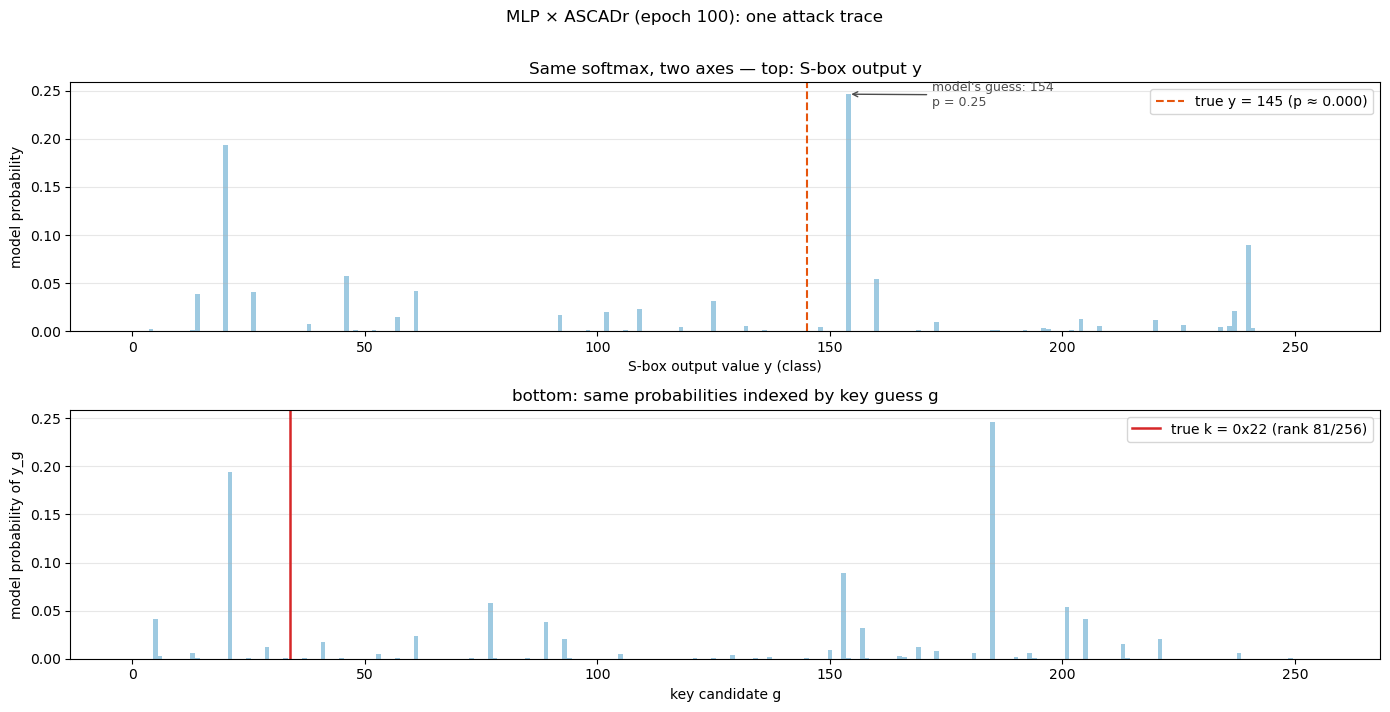

In [5]:
# Same 256 probabilities, two horizontal axes: y (network output) and g
# (key guess). For fixed p, y_g = Sbox[p ⊕ g] is a bijection, so the bottom
# panel is only a reordering of the top — not a second model.
probs_by_key = probs[H[:, TRACE]]
rank_of_true_key = int((probs_by_key > probs_by_key[true_key]).sum()) + 1
print(f"same softmax, remapped to key guesses: true key rank {rank_of_true_key} of 256")

fig, (ax_y, ax_g) = plt.subplots(2, 1, figsize=(14, 7), sharey=True)

ax_y.bar(np.arange(256), probs, color="#9ecae1", width=1.0)
ax_y.axvline(true_class, color="#e6550d", ls="--", lw=1.5,
             label=f"true y = {true_class} (p ≈ {probs[true_class]:.3f})")
ax_y.annotate(f"model's guess: {guess_class}\np = {probs[guess_class]:.2f}",
              xy=(guess_class, probs[guess_class]),
              xytext=(guess_class + 18, probs[guess_class] * 0.95),
              arrowprops=dict(arrowstyle="->", color="0.3"),
              fontsize=9, color="0.3")
ax_y.set_title("Same softmax, two axes — top: S-box output y")
ax_y.set_xlabel("S-box output value y (class)")
ax_y.set_ylabel("model probability")
ax_y.grid(alpha=0.3, axis="y")
ax_y.legend(loc="upper right")

ax_g.bar(np.arange(256), probs_by_key, color="#9ecae1", width=1.0)
ax_g.axvline(
    true_key, color="#d62728", ls="-", lw=1.8,
    label=f"true k = 0x{true_key:02x} (rank {rank_of_true_key}/256)",
)
ax_g.set_title("bottom: same probabilities indexed by key guess g")
ax_g.set_xlabel("key candidate g")
ax_g.set_ylabel("model probability of y_g")
ax_g.grid(alpha=0.3, axis="y")
ax_g.legend(loc="upper right")

fig.suptitle("MLP × ASCADr (epoch 100): one attack trace", y=1.01)
fig.tight_layout()
fig.savefig(out / "04_prediction.png", dpi=150, bbox_inches="tight")
print("saved:", out / "04_prediction.png")
plt.show()

The top panel is what the network emits: a distribution over `y`. The
bottom panel uses the public map `y_g = Sbox[p ⊕ g]` to place each of
those same probabilities on the corresponding key guess. No new inference —
only a change of axis. Orange on the bottom is the true key byte; it is
still not the tallest bar (masking). Later we will *sum* bottom-style
scores across traces; we will not average many top panels.

The output is *confident* — one class collects ~25% of the probability mass
— but it is not the true value. This is the mask at work: a single trace
carries the masked value `Sbox[plaintext ⊕ key] ⊕ mask`, and without
knowing the mask the network can only make an educated guess.

Is there any signal per trace at all? Over the first 500 attack traces:

In [6]:
N = 500

probs_n = model.predict(dataset.x_attack[:N], verbose=0)
p_true = probs_n[np.arange(N), dataset.attack_labels[:N]]

print(f"mean probability of the true value: {p_true.mean():.4f}"
      f"  (uniform baseline: {1 / 256:.4f})")
print(f"traces where the best guess is right: {int((probs_n.argmax(axis=1) == dataset.attack_labels[:N]).sum())} of {N}")

mean probability of the true value: 0.0089  (uniform baseline: 0.0039)
traces where the best guess is right: 4 of 500


The true value receives roughly **twice** the uniform probability — a real
but weak per-trace signal, exactly as the masking countermeasure intends.
One trace is not an attack. Many traces are.

## 4. Accumulating evidence

Why not just average many softmax plots like the one above? That figure's
horizontal axis is the S-box output `y`. Each encryption uses a different
plaintext byte `p`, so the true `y = Sbox[p ⊕ k]` sits on a **different
class** almost every time. Averaging those vectors blurs peaks that were
never aligned. The axis that stays fixed is the key byte — still unknown —
so each softmax is rewritten as one number per key guess `g`:

```text
y_g = Sbox[p ⊕ g]          # public
take P(y_g | power)        # from that trace's softmax
```

If traces are independent, the combined score for `g` is the *product* of
those probabilities. Products of many small numbers underflow in floating
point, so we take logs: the product becomes a **sum of log-probabilities**.
Log does not change which `g` wins.

A tiny two-trace example. Under candidate `g`, the model assigns the first
trace's implied value a probability of 0.02 and the second trace's implied
value 0.05; under candidate `h`, 0.01 and 0.20:

```text
evidence(g) = log(0.02) + log(0.05) = −3.9 − 3.0 = −6.9
evidence(h) = log(0.01) + log(0.20) = −4.6 − 1.6 = −6.2
```

Two traces, and candidate `h` is already ahead — although `g` won the
second trace alone. Every trace casts a vote for every candidate; the
candidate whose votes are *consistently* least bad wins in the long run.

Now for all 256 candidates over the attack set:

In [7]:
predictions = model.predict(dataset.x_attack, verbose=0)   # (n_attack, 256)
log_pred = np.log(predictions + 1e-36)

The bar charts below are **not** stacked softmaxes. The horizontal axis is
now the key candidate `g`. Each panel sums log P(y_g) over the first `n`
attack traces (fixed order). Orange = true key byte; the title is its rank:

saved: /workspace/outputs/figures/04_evidence_progress.png


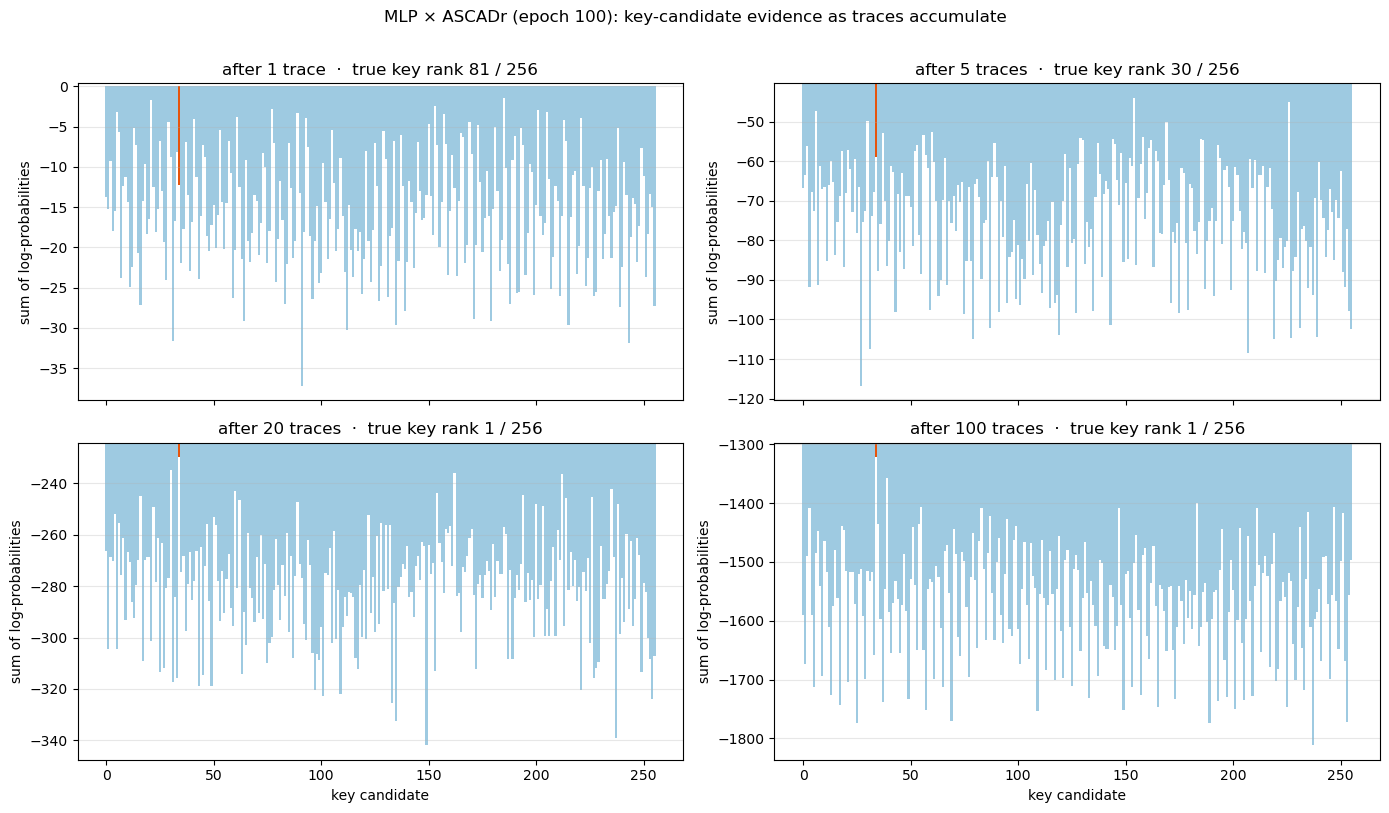

In [8]:
checkpoints = [1, 5, 20, 100]
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, n in zip(axes.ravel(), checkpoints):
    ev = log_pred[np.arange(n), H[:, :n]].sum(axis=1)
    rank = int((ev > ev[true_key]).sum()) + 1
    colors = np.full(256, "#9ecae1")
    colors[true_key] = "#e6550d"
    ax.bar(np.arange(256), ev, color=colors, width=1.0)
    ax.set_title(f"after {n} trace{'s' if n > 1 else ''}  ·  true key rank {rank} / 256")
    ax.set_ylabel("sum of log-probabilities")
    ax.grid(alpha=0.3, axis="y")
    lo, hi = ev.min(), ev.max()
    pad = 0.05 * (hi - lo + 1e-9)
    ax.set_ylim(lo - pad, hi + pad)

axes[1, 0].set_xlabel("key candidate")
axes[1, 1].set_xlabel("key candidate")
fig.suptitle(
    "MLP × ASCADr (epoch 100): key-candidate evidence as traces accumulate",
    y=1.01,
)
fig.tight_layout()
fig.savefig(out / "04_evidence_progress.png", dpi=150, bbox_inches="tight")
print("saved:", out / "04_evidence_progress.png")
plt.show()

In [9]:
for n in checkpoints + [400, 1000]:
    ev = log_pred[np.arange(n), H[:, :n]].sum(axis=1)
    rank = int((ev > ev[true_key]).sum()) + 1
    print(f"after {n:5d} traces: rank of the true key = {rank} of 256")

after     1 traces: rank of the true key = 81 of 256
after     5 traces: rank of the true key = 30 of 256
after    20 traces: rank of the true key = 1 of 256
after   100 traces: rank of the true key = 1 of 256
after   400 traces: rank of the true key = 1 of 256
after  1000 traces: rank of the true key = 1 of 256


After twenty traces in this fixed order the true byte is already rank 1.
The same ranking after 1,000 traces makes the gap unmistakable:

In [10]:
N_EVIDENCE = 1000

evidence = log_pred[np.arange(N_EVIDENCE), H[:, :N_EVIDENCE]].sum(axis=1)
rank_true = int((evidence > evidence[true_key]).sum()) + 1

print(f"accumulated evidence over {N_EVIDENCE} traces:")
print(f"  candidate 0x{true_key:02x} (true): {evidence[true_key]:10.1f}  -> rank {rank_true} of 256")
best_wrong = int(np.argmax(np.where(np.arange(256) == true_key, -np.inf, evidence)))
print(f"  best wrong candidate 0x{best_wrong:02x}: {evidence[best_wrong]:10.1f}")

accumulated evidence over 1000 traces:
  candidate 0x22 (true):   -12064.7  -> rank 1 of 256
  best wrong candidate 0xc2:   -13694.4


saved: /workspace/outputs/figures/04_key_ranking.png


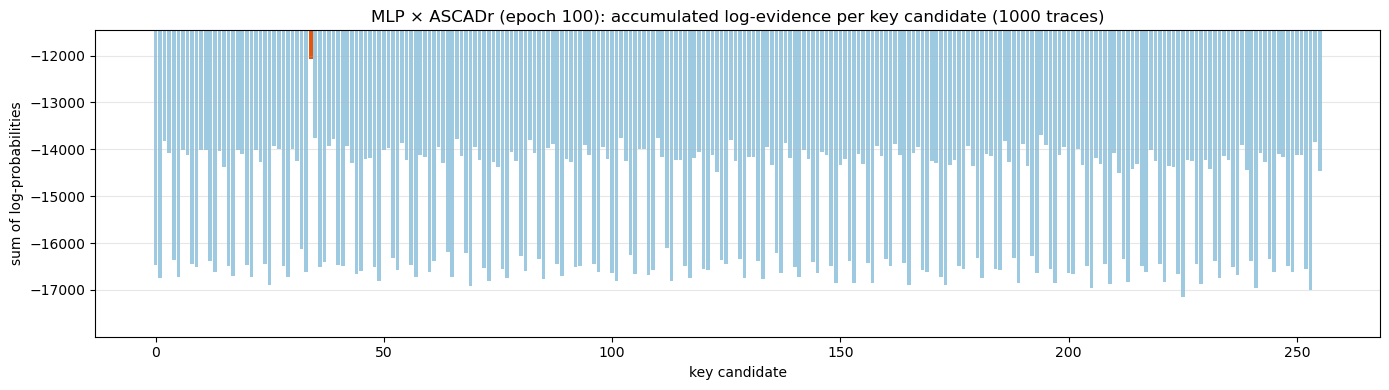

In [11]:
fig, ax = plt.subplots(figsize=(14, 4))

colors = np.full(256, "#9ecae1")
colors[true_key] = "#e6550d"
ax.bar(np.arange(256), evidence, color=colors)

ax.set_title(f"MLP × ASCADr (epoch 100): accumulated log-evidence per key candidate ({N_EVIDENCE} traces)")
ax.set_xlabel("key candidate")
ax.set_ylabel("sum of log-probabilities")
ax.set_ylim(evidence.min() * 1.05, evidence.max() * 0.95)
ax.grid(alpha=0.3, axis="y")

fig.tight_layout()
fig.savefig(out / "04_key_ranking.png", dpi=150)
print("saved:", out / "04_key_ranking.png")
plt.show()

One orange bar stands out: the true key byte. The model never spoke about
keys — it only ever assigned probabilities to *values* — yet summing its
verdicts over 1,000 traces leaves the true candidate far ahead of the 255
runners-up.

## 5. Guessing entropy: scoring a key recovery

The evidence chart shows one battle. But which 1,000 traces we happen to
draw matters, so the standard metric averages over many battles. The
**guessing entropy** (GE):

1. Draw a random subset of the attack traces.
2. Accumulate the log-evidence of each candidate over the subset, and rank
   the 256 candidates.
3. The rank of the true key, averaged over many draws, is the guessing
   entropy: GE = 1 means the attack points at the correct key; GE ≈ 128
   means blind guessing.

We use the package's implementation, averaged over 40 random draws of 4,000
attack traces (the random seed is fixed for reproducibility):

In [12]:
np.random.seed(42)

from feature_emergence.profiling_and_attack import guessing_entropy

final_ge, ge_curve, nt_for_ge1 = guessing_entropy(
    predictions,
    H,                       # 256 x n_attack: label under every key guess
    true_key,                # the true key byte
    key_rank_attack_traces=4000,
)

GE = 1.0
Number of traces to reach GE = 1: 86


saved: /workspace/outputs/figures/04_guessing_entropy.png


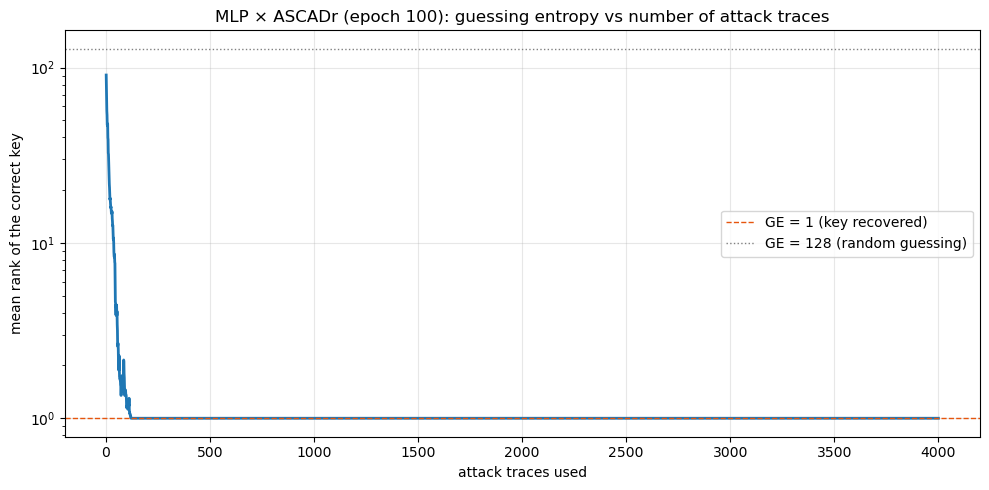

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

n_seen = np.arange(1, len(ge_curve) + 1)
ax.plot(n_seen, ge_curve, lw=2)
ax.axhline(1, color="#e6550d", ls="--", lw=1, label="GE = 1 (key recovered)")
ax.axhline(128, color="grey", ls=":", lw=1, label="GE = 128 (random guessing)")

ax.set_title("MLP × ASCADr (epoch 100): guessing entropy vs number of attack traces")
ax.set_xlabel("attack traces used")
ax.set_ylabel("mean rank of the correct key")
ax.set_yscale("log")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(out / "04_guessing_entropy.png", dpi=150)
print("saved:", out / "04_guessing_entropy.png")
plt.show()

The curve collapses from ~128 (blind guessing) to 1 within ~100 traces, and
the correct key holds rank 1 from trace 86 on. In practice: about 86 power
measurements of the device are enough to identify one key byte with
certainty — against 256 pure guesses. Each trace contributed only a whisper
of evidence; combined, the whispers decide. The attack works.

## Takeaways

- The attacker knows the plaintexts and enumerates 256 key candidates; each
  candidate implies a different label for every trace.
- Masking keeps *single* traces safe: the model's best guess is wrong on
  496 of 500 attack traces, and the true value gets about twice the uniform
  probability — weak, but systematically above chance.
- Summed log-probabilities turn those weak signals into a clear ranking of
  the 256 candidates: the true key stands out after a few hundred traces.
- The guessing entropy — the averaged rank of the true key — collapses to 1
  within ~86 traces: the epoch-100 model recovers the key byte.
- This is the model *at the end of training*. What happened *during* those
  100 epochs is the question of the next chapter.